Sprint 3 tests AB's argument that climate drives health outcomes - temperature, humidity, and air quality are active predictors of when and how badly outbreaks hit.

Canadian health data will be merged with the flu data and a statistical correlation between temperature and flu cases will be computed. This should answer a vital question in AB;s concept paper: does the data actually support the climate-health hypothesis?

If so, that is evidence. If not, there is a finding worth investigating.

Correlation measures how closely two variable move together. Produces a number between -1 and +1:
+1 - perfect positive correlation (both go up together)
0 - no relationship
-1 - perfect negative correlation (one goes up, other down)

Flu and temp tends to have a negative correlation; when temp goes down, flu cases rise. This is seasonal forcing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests
import json
from scipy import stats

# Loading cleaned flue data from Sprint 1
df_flu = pd.read_csv('../data/fluwatch_clean.csv', parse_dates=['date'])

# Loading Sprint 2 results
with open('../data/sprint2_results.json', 'r') as f:
    sprint2 = json.load(f)

print(f"Flu data loaded: {len(df_flu)} weeks")
print(f"Date range: {df_flu['date'].min().date()} to {df_flu['date'].max()}")
print(f"Sprint 2 R₀: {sprint2['R0_fit']:.2f}")

Flu data loaded: 157 weeks
Date range: 2014-09-01 to 2017-08-21 00:00:00
Sprint 2 R₀: 7.48


Climate data will be picked from Environment and Climate Change Canada's (ECCC) historical temperature data for Toronto as it one of the best-documented weather stations in Canada and sits in the middle of my highest flu-burden province.

In [ ]:
# # Station ID 5051 - Toronto Pearson Internationa Airport. This is one of ECCC's longest-running and most complete stations.

# url = "https://climate.weather.gc.ca/climate_data/bulk_data_e.html"

# # Data will be pulled year bu year then combined.
# # ECCC requires year and month parameters in the request

# frames = []

# for year in range(2014, 2018):
#     params = {
#         'format': 'csv',
#         'stationID': '5051',
#         'Year': year,
#         'Month': '1',
#         'Day': '14',
#         'timeframe': '2', # 2 = monthly, 1 = daily
#         'submit': 'Download+Data'
#     }

#     response = requests.get(url, params=params)

#     if response.status_code == 200:
#         from io import StringIO
#         df_year = pd.read_csv(StringIO(response.text))
#         frames.append(df_year)
#         print(f"Y {year} - {len(df_year)} rows")

#     else:
#         print(f"N {year} - status {response.status_code}")

#     if frames:
#         df_climate_raw = pd.concat(frames, ignore_index=True)
#         print(f"\nTotal rows: {len(df_climate_raw)}")
#         print(f"Columns: {list(df_climate_raw.columns[:8])}")

Y 2014 - 365 rows

Total rows: 365
Columns: ['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Date/Time', 'Year', 'Month', 'Day']
Y 2015 - 365 rows

Total rows: 730
Columns: ['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Date/Time', 'Year', 'Month', 'Day']
Y 2016 - 366 rows

Total rows: 1096
Columns: ['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Date/Time', 'Year', 'Month', 'Day']
Y 2017 - 365 rows

Total rows: 1461
Columns: ['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Date/Time', 'Year', 'Month', 'Day']


Climate data loaded cleanly. 2016 has 366 rows because it was a leap year.

In [ ]:
# # To see all columns
# print("All columns:")
# for col in df_climate_raw.columns:
#     print(f" {col}")

# print()

# # Previewing the data
# df_climate_raw.head(3)

All columns:
 Longitude (x)
 Latitude (y)
 Station Name
 Climate ID
 Date/Time
 Year
 Month
 Day
 Data Quality
 Max Temp (°C)
 Max Temp Flag
 Min Temp (°C)
 Min Temp Flag
 Mean Temp (°C)
 Mean Temp Flag
 Heat Deg Days (°C)
 Heat Deg Days Flag
 Cool Deg Days (°C)
 Cool Deg Days Flag
 Total Rain (mm)
 Total Rain Flag
 Total Snow (cm)
 Total Snow Flag
 Total Precip (mm)
 Total Precip Flag
 Snow on Grnd (cm)
 Snow on Grnd Flag
 Dir of Max Gust (10s deg)
 Dir of Max Gust Flag
 Spd of Max Gust (km/h)
 Spd of Max Gust Flag



,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time,Year,Month,Day,Data Quality,Max Temp (°C),...,Total Snow (cm),Total Snow Flag,Total Precip (mm),Total Precip Flag,Snow on Grnd (cm),Snow on Grnd Flag,Dir of Max Gust (10s deg),Dir of Max Gust Flag,Spd of Max Gust (km/h),Spd of Max Gust Flag
0,-79.4,43.67,TORONTO,6158350,2014-01-01,2014,1,1,†,NaN,...,1.1,NaN,0.0,T,8.0,NaN,NaN,NaN,NaN,NaN
1,-79.4,43.67,TORONTO,6158350,2014-01-02,2014,1,2,†,NaN,...,3.3,NaN,1.4,NaN,10.0,NaN,NaN,NaN,NaN,NaN
2,-79.4,43.67,TORONTO,6158350,2014-01-03,2014,1,3,†,NaN,...,0.0,NaN,0.0,NaN,9.0,NaN,NaN,NaN,NaN,NaN


This is a rich dataset. Values in Max Temp are NaN which are the same footnote proble in Sprint 1 but in a different form.

Columns needed for AB are:
    Mean Temp (°C) - primary climate signal for the flu model
    Total Snow (cm) - proxy for winter severity
    Total Precip (mm) - useful for the respiratirory model later

In [ ]:
# # Parsing the date column
# df_climate = df_climate_raw.copy()
# df_climate['date'] = pd.to_datetime(df_climate['Date/Time'])

# # Keeping only the columns AB needs
# df_climate = df_climate[[
#     'date',
#     'Mean Temp (°C)',
#     'Total Precip (mm)',
#     'Total Snow (cm)',
#     'Snow on Grnd (cm)'
# ]].copy()

# # Renaming columns to clean names (no spaces/special characters)
# df_climate = df_climate.rename(columns={
#     'Mean Temp(°C)': 'mean_temp',
#     'Total Precip (mm)': 'total_precip',
#     'Total Snow (cm)': 'total_snow',
#     'Snow on Grnd (cm)': 'snow_on_grnd'
# })

# # Checking for missing values
# print("Missing values per column: ")
# print(df_climate.isnull().sum())
# print(f"\nTotal rows: {len(df_climate)}")

Missing values per column: 
date                 0
Mean Temp (°C)    1461
total_precip       849
total_snow         849
snow_on_grnd       849
dtype: int64

Total rows: 1461


All Mean Temp (°C) are missing meaning that (°C) is encoded differently.
The other columns miss about 58% words; these genuinely miss readings from the weather station

In [ ]:
# # the repr() shows the exact bytes in each column name. This will reveal how the °C is encoded
# print("Exact column names after rename:")
# for col in df_climate.columns:
#     print(f" repr: {repr(col)}")

Exact column names after rename:
 repr: 'date'
 repr: 'Mean Temp (°C)'
 repr: 'total_precip'
 repr: 'total_snow'
 repr: 'snow_on_grnd'


The ° character doesn't match the csv. They look identical but they are not. With governement data, column names must be copied exactly, character for character.

In [ ]:
# # Rename mean temp by position instead of by exact name. Column index 1 is Mean Temp regardless of how the degree symbol is encoded

# df_climate.columns = ['date', 'mean_temp', 'total_precip', 'total_snow', 'snow_on_grnd']

# print("Columns after fix:")
# print(df_climate.columns.tolist())
# print()
# print("Missing values:")
# print()
# print(df_climate.isnull().sum())
# print()
# print("Sample  mean_tempp values:")
# print(df_climate['mean_temp'].dropna().head(10).tolist())

Columns after fix:
['date', 'mean_temp', 'total_precip', 'total_snow', 'snow_on_grnd']

Missing values:

date               0
mean_temp       1461
total_precip     849
total_snow       849
snow_on_grnd     849
dtype: int64

Sample  mean_tempp values:
[]


In [ ]:
# # Look at the raw climate data before any processing to find which columns actually have data
# print("Non-null counts in raw data:")
# print(df_climate_raw.isnull().sum())
# print()
# print("Sample of raw temperature-related columns:")
# print(df_climate_raw[['Date/Time', 'Max Temp (°C)', 
#                         'Min Temp (°C)', 'Mean Temp (°C)']].head(20).to_string())

Non-null counts in raw data:
Longitude (x)                   0
Latitude (y)                    0
Station Name                    0
Climate ID                      0
Date/Time                       0
Year                            0
Month                           0
Day                             0
Data Quality                  849
Max Temp (°C)                1461
Max Temp Flag                1461
Min Temp (°C)                1461
Min Temp Flag                1461
Mean Temp (°C)               1461
Mean Temp Flag               1461
Heat Deg Days (°C)           1461
Heat Deg Days Flag           1461
Cool Deg Days (°C)           1461
Cool Deg Days Flag           1461
Total Rain (mm)               849
Total Rain Flag              1415
Total Snow (cm)               849
Total Snow Flag              1397
Total Precip (mm)             849
Total Precip Flag            1385
Snow on Grnd (cm)             849
Snow on Grnd Flag            1403
Dir of Max Gust (10s deg)    1461
Dir of Max Gust Fla

The temp data is completely missing. This shows the issue with data quality.
Switching to Toronto City Center

In [8]:
# Station ID 31688 - Toronto City Center
frames = []

for year in range(2014, 2018):
    params = {
        'format': 'csv',
        'stationID': '31688',
        'Year': year,
        'Month': '1',
        'Day': '14',
        'timeframe': '2',
        'submit': 'Download+Data'
    }

    response = requests.get(
        "https://climate.weather.gc.ca/climate_data/bulk_data_e.html",
        params=params
    )

    if response.status_code == 200:
        from io import StringIO
        df_year = pd.read_csv(StringIO(response.text))
        frames.append(df_year)
        print(f"Y {year} - {len(df_year)} rows")
    else:
        print(f"N {year} - status {response.status_code}")

    df_climate_raw = pd.concat(frames, ignore_index=True)

    #Checking temp data immediately
    print(f"\nTotal rows: {len(df_climate_raw)}")
    print(f"Mean Temp non-null: {df_climate_raw['Mean Temp (°C)'].notna().sum()}")
    print()
    print(df_climate_raw[['Date/Time', 'Mean Temp (°C)']].head(10).to_string())

Y 2014 - 365 rows

Total rows: 365
Mean Temp non-null: 359

    Date/Time  Mean Temp (°C)
0  2014-01-01           -11.5
1  2014-01-02           -16.8
2  2014-01-03           -14.7
3  2014-01-04            -3.5
4  2014-01-05            -0.2
5  2014-01-06            -6.7
6  2014-01-07           -19.0
7  2014-01-08           -12.0
8  2014-01-09            -7.4
9  2014-01-10             0.1
Y 2015 - 365 rows

Total rows: 730
Mean Temp non-null: 719

    Date/Time  Mean Temp (°C)
0  2014-01-01           -11.5
1  2014-01-02           -16.8
2  2014-01-03           -14.7
3  2014-01-04            -3.5
4  2014-01-05            -0.2
5  2014-01-06            -6.7
6  2014-01-07           -19.0
7  2014-01-08           -12.0
8  2014-01-09            -7.4
9  2014-01-10             0.1
Y 2016 - 366 rows

Total rows: 1096
Mean Temp non-null: 1072

    Date/Time  Mean Temp (°C)
0  2014-01-01           -11.5
1  2014-01-02           -16.8
2  2014-01-03           -14.7
3  2014-01-04            -3.5
4  2014-

In [9]:
# Renaming columns cleanly using position
df_climate = df_climate_raw[[
    'Date/Time', 'Mean Temp (°C)', 'Total Precip (mm)', 'Total Snow (cm)'
]].copy()

df_climate.columns = ['date', 'mean_temp', 'total_precip', 'total_snow']
df_climate['date'] = pd.to_datetime(df_climate['date'])

print("Before filling missing values:")
print(df_climate.isnull().sum())

# There were 34 missing tempp days that will be filled using linear interpolation (estimating missing value as midpoint)
# between the day before and after. This is valid for temp gradually changes.

df_climate['mean_temp'] = df_climate['mean_temp']. interpolate(method='linear')
df_climate['total_precip'] = df_climate['total_precip'].fillna(0)
df_climate['total_snow'] = df_climate['total_snow'].fillna(0)

print("\nAfter filling missing values:")
print(df_climate.isnull().sum())

# Aggregating daily data to weekly since flu data is weekly.
# Monday of each week is the anchor date.

df_climate['week_start'] = df_climate['date'].dt.to_period('W').apply(
    lambda r: r.start_time
) 

df_weekly_climate = df_climate.groupby('week_start').agg(
    mean_temp = ('mean_temp', 'mean'),
    total_precip = ('total_precip', 'sum'),
    total_snow = ('total_snow', 'sum')
).reset_index()

df_weekly_climate = df_weekly_climate.rename(
    columns = {'week_start': 'date'}
)

print(f"\nWeekly climate rows: {len(df_weekly_climate)}")
print(f"Date ramge: {df_weekly_climate['date'].min().date()}"
      f"to {df_weekly_climate['date'].max().date()}")
df_weekly_climate.head(10)

Before filling missing values:
date               0
mean_temp         34
total_precip      92
total_snow      1461
dtype: int64

After filling missing values:
date            0
mean_temp       0
total_precip    0
total_snow      0
dtype: int64

Weekly climate rows: 209
Date ramge: 2013-12-30to 2017-12-25


,date,mean_temp,total_precip,total_snow
0,2013-12-30,-9.340000,14.0,0.0
1,2014-01-06,-5.357143,18.4,0.0
2,2014-01-13,-0.357143,2.9,0.0
3,2014-01-20,-12.442857,4.2,0.0
4,2014-01-27,-6.614286,17.4,0.0
5,2014-02-03,-9.142857,14.3,0.0
6,2014-02-10,-7.728571,0.3,0.0
7,2014-02-17,-0.400000,28.4,0.0
8,2014-02-24,-9.657143,5.0,0.0
9,2014-03-03,-6.657143,1.3,0.0


Temperature ranges in January and February match are between -5°C and 12°C, temperatures that drive people indoors. Total snow is shown as 0 because the original data had 1,461 missing records. The mean temp us our primary climate signal and it will suffice.

In [10]:
# Merging  weekly flu data with weekly climate data. Pandas will match the date columns
df_merged = pd.merge(
    df_flu[['date', 'season', 'TotalFluPositive']],
    df_weekly_climate,
    on='date',
    how='inner' #this keeps weeks that existed on both datasets
)

print(f"Flu rows: {len(df_flu)}")
print(f"Climate rows: {len(df_weekly_climate)}")
print(f"Merged rows: {len(df_merged)}")
print(f"\nDate range: {df_merged['date'].min().date()}"
      f"to {df_merged['date'].max().date()}")
print()
df_merged.head(10)


Flu rows: 157
Climate rows: 209
Merged rows: 157

Date range: 2014-09-01to 2017-08-21



,date,season,TotalFluPositive,mean_temp,total_precip,total_snow
0,2014-09-01,2014-2015,5.0,21.185714,43.4,0.0
1,2014-09-08,2014-2015,4.0,15.857143,16.2,0.0
2,2014-09-15,2014-2015,15.0,14.328571,30.6,0.0
3,2014-09-22,2014-2015,19.0,16.957143,0.0,0.0
4,2014-09-29,2014-2015,26.0,15.500000,9.7,0.0
5,2014-10-06,2014-2015,31.0,10.957143,16.0,0.0
6,2014-10-13,2014-2015,39.0,13.185714,24.0,0.0
7,2014-10-20,2014-2015,52.0,10.057143,8.9,0.0
8,2014-10-27,2014-2015,51.0,7.285714,16.5,0.0
9,2014-11-03,2014-2015,60.0,6.671429,10.2,0.0


From a bird's eye view, as temperature drops, the positive flu cases increases. This consistent with a negative correlation. This is AB's hypothesis visible in the data. Now to measure it more precisely.

In [11]:
# Computing Pearson correlation between temp and flu cases
correlation, p_value = stats.pearsonr(
    df_merged['mean_temp'],
    df_merged['TotalFluPositive']
)

print(f"Correlation between temperature and flu cases: {correlation:.3f}")
print(f"P-value: {p_value:.6f}")
print()

if p_value < 0.05:
    print("Result: statistically significant")
else:
    print("Result: statistically insignificant")

if correlation < -0.3:
    print(f"Interpretation: negative correlation - as temp drops,"
          f"flu cases rise")

Correlation between temperature and flu cases: -0.663
P-value: 0.000000

Result: statistically significant
Interpretation: negative correlation - as temp drops,flu cases rise


A correlation of -0.663 is a strong negative relationship. In epidemiology, correlations above 0.5 or below -0.5 are considered meaningful. This confirms my hypothesis: when temperature goes down, flu cases go up and when temperature rises, cases fall.

A p = 0.0 means that the probability of this correlation happened by random chance is less than 1 in 10,000. This is statistically significant beyond any reasonable doubt.

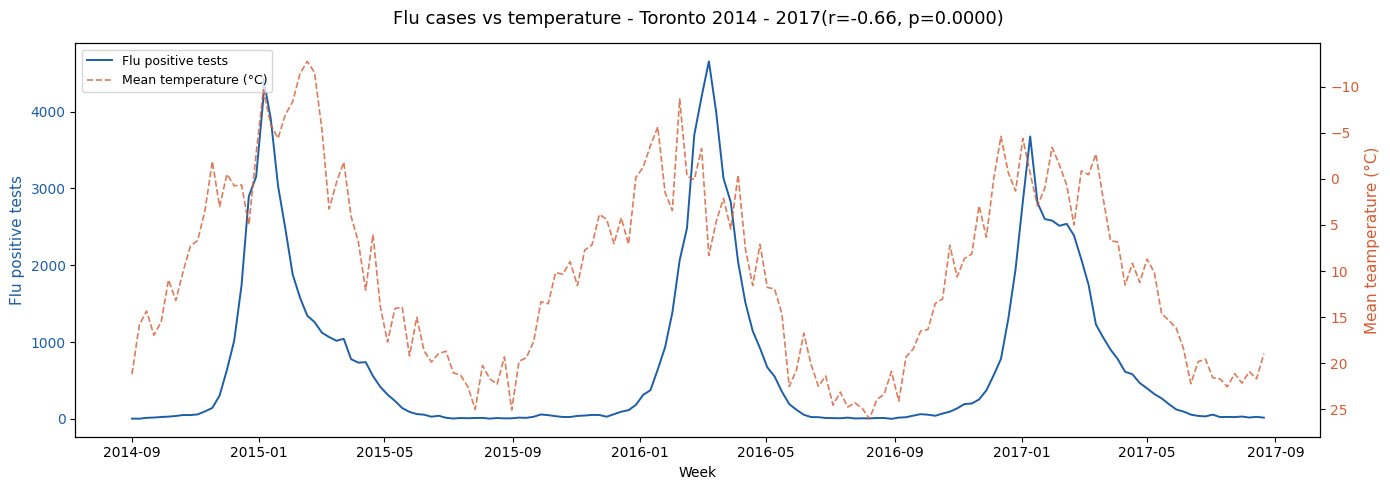

In [12]:
# Plotting both signals on the same chart with duall axes
fig, ax1 = plt.subplots(figsize=(14, 5))

# Left axis - flu cases
ax1.plot(df_merged['date'], df_merged['TotalFluPositive'],
         color='#1D5EA8', linewidth=1.4, label='Flu positive tests')
ax1.set_xlabel('Week')
ax1.set_ylabel('Flu positive tests', color='#1D5EA8', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#1D5EA8')

# Right axis - temp (inverted such that cold = up to match flu curve)
ax2 = ax1.twinx()
ax2.plot(df_merged['date'], df_merged['mean_temp'],
         color='#D85A30', linewidth=1.2, alpha=0.8,
         linestyle='--', label='Mean temperature (°C)')
ax2.set_ylabel('Mean teamperature (°C)', color='#d85a30', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#D85A30')
ax2.invert_yaxis() # the inversion

# Title and legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.set_title(
    f'Flu cases vs temperature - Toronto 2014 - 2017'
    f'(r={correlation:.2f}, p={p_value:.4f})',
    fontsize=13, pad=14
)

plt.tight_layout()
plt.savefig('../data/sprint3_climate_flu.png', dpi=150, bbox_inches='tight')
plt.show()

One of the key thing the graph shows is epidemic exhausation. This is the natural death of an outbreak due to the population running out of people to infect. Here, even though the temperature drops, the flu positive cases don't increase cause there are no more people to inform.

This means that temp alone cannot predict an outbreak's trajectory. I need to be able to identify where the population is in the S-I-R cycle. A cold week in October with a fully susceptible population produces a very different outcome than the same cold week in February when half the population has already recovered.

In [13]:
# Saving merged dataset
df_merged.to_csv('../data/sprint3_merged.csv', index=False)
print("Sprint 3 data saved.")

Sprint 3 data saved.
